# VBET validation of raw valley-width and confinement-ratio values

This notebook validates the manuscript's **continuous** confinement measurement, not its downstream cluster labels. The primary paired comparison is:

The paper-side variables `ER_inn` and `ER_out` are already dimensionless one-sided confinement ratios (valley-edge intercept divided by bend width). Thus the primary paired comparison is:

$$R_{paper}=ER_{inn}+ER_{out}; R_{VBET}=integrated_width/bendWidths$$

For a width-in-metres comparison, multiply the paper ratio by the same bend width:

$$W_{paper}=R_{paper} bendWidths; W_{VBET}=integrated_width.$$

A uniform multiplicative difference between products is not, by itself, a failure for a relative confinement classification. It should be reported as a calibration offset. The concern is weak rank agreement, large unexplained scatter, or a scale-dependent bias that changes the ordering of confined and unconfined settings.

In [31]:
from pathlib import Path
import duckdb

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.style.use('default')
pd.set_option('display.max_columns', 100)

## Inputs and analysis choices

The matched DGO table was created by `pipeline.extract_vbet_dgo_matches`. The 150 m screen is a starting QA choice, not a scientific threshold; rerun the sensitivity section below at 100, 150, 200, and 250 m after visual inspection in QGIS.

In [32]:
REPO = Path.cwd().resolve()
if not (REPO / 'results').exists():
    REPO = REPO.parent

MATCHES = REPO / 'results/vbet_validation/pnw_dgo_bend_matches.parquet'
# Bend widths used to calculate ER_inn and ER_out in the submitted workflow.
PAPER_BEND_VALUES = '/Volumes/PhD/confinement/results/single_values/global_50_combined.parquet'

MATCH_DISTANCE_M = 150
MIN_DGOS_PER_BEND = 3

assert MATCHES.exists(), f'Missing matched DGO table: {MATCHES}'
assert Path(PAPER_BEND_VALUES).exists(), f'Missing paper bend-value table: {PAPER_BEND_VALUES}'
print(f'Using {MATCHES.name} and source bend widths from {Path(PAPER_BEND_VALUES).name}')

Using pnw_dgo_bend_matches.parquet and source bend widths from global_50_combined.parquet


## Build the paired bend table

The implementation confirms that `ER_inn` and `ER_out` are one-sided **ratios**, each calculated as the valley-edge intercept divided by the bend width. Their sum is therefore the paper's two-sided width ratio. `bendWidths` is recovered from the source bend-value table using the exact `combined_reach_id` + `bendDistOut` key.

Before treating this as a manuscript result, inspect several matched locations in QGIS. In particular, decide how to handle one-sided/no-intersection profiles (missing one ER value) rather than silently interpreting them as a zero-width side.

In [33]:
all_matches = pd.read_parquet(MATCHES)
required = {'bendID', 'combined_reach_id_x', 'bendDistOut', 'ER_inn', 'ER_out', 'integrated_width', 'match_distance_m', 'dgoid'}
missing = required.difference(all_matches.columns)
assert not missing, f'Missing expected fields: {missing}'

# The manuscript bend layer uses this name because it was created in a spatial join.
all_matches = all_matches.rename(columns={'combined_reach_id_x': 'combined_reach_id'})
matches = all_matches.loc[all_matches['match_distance_m'] <= MATCH_DISTANCE_M].copy()

# Only read the North American rows and three required fields from the 18 GB source parquet.
with duckdb.connect() as con:
    paper_bend_widths = con.execute(
        f"SELECT combined_reach_id, bendDistOut, bendWidths FROM read_parquet('{PAPER_BEND_VALUES}') WHERE continent = 'na'"
    ).fetchdf()
paper_bend_widths = paper_bend_widths.drop_duplicates(['combined_reach_id', 'bendDistOut'])

bend = (matches.groupby('bendID', as_index=False)
        .agg(combined_reach_id=('combined_reach_id', 'first'),
             n_vbet_dgos=('dgoid', 'size'),
             paper_inner_ratio=('ER_inn', 'first'),
             paper_outer_ratio=('ER_out', 'first'),
             bendDistOut=('bendDistOut', 'first'),
             vbet_integrated_width_m=('integrated_width', 'median'),
             vbet_channel_width_m=('vbet_channel_width', 'median'),
             vbet_confinement_ratio=('vbet_confinement_ratio', 'median'),
             median_match_distance_m=('match_distance_m', 'median')))
bend = bend.merge(paper_bend_widths, on=['combined_reach_id', 'bendDistOut'], how='left', validate='many_to_one')
bend['paper_ratio'] = bend['paper_inner_ratio'] + bend['paper_outer_ratio']
bend['paper_valley_width_m'] = bend['paper_ratio'] * bend['bendWidths']
bend['vbet_ratio'] = bend['vbet_integrated_width_m'] / bend['bendWidths']
bend['vbet_own_ratio'] = bend['vbet_integrated_width_m'] / bend['vbet_channel_width_m']

finite_positive = ['paper_valley_width_m', 'vbet_integrated_width_m', 'bendWidths', 'paper_ratio', 'vbet_ratio']
for column in finite_positive:
    bend[column] = pd.to_numeric(bend[column], errors='coerce')
analysis = bend.loc[(bend['n_vbet_dgos'] >= MIN_DGOS_PER_BEND) &
                    np.isfinite(bend[finite_positive]).all(axis=1) &
                    (bend[finite_positive] > 0).all(axis=1)].copy()
print(f'{len(matches):,} matched DGOs after distance screen')
print(f'{len(analysis):,} paired bends with ≥{MIN_DGOS_PER_BEND} DGOs and valid widths')
print(f"{bend['bendWidths'].notna().sum():,}/{len(bend):,} bends recovered an exact source bend width")
analysis.describe(percentiles=[.05, .25, .5, .75, .95])[['paper_valley_width_m', 'vbet_integrated_width_m', 'paper_ratio', 'vbet_ratio']]

27,803 matched DGOs after distance screen
2,740 paired bends with ≥3 DGOs and valid widths
4,234/4,234 bends recovered an exact source bend width


,paper_valley_width_m,vbet_integrated_width_m,paper_ratio,vbet_ratio
count,2740.000000,2740.000000,2740.000000,2740.000000
mean,335.546959,115.894214,5.042346,1.667397
std,474.669695,123.710016,5.896384,1.611144
min,38.368915,9.965079,1.000000,0.031486
5%,70.581494,15.651521,1.276648,0.264686
25%,127.613927,44.497594,1.941303,0.825275
50%,203.291900,76.016965,2.993188,1.269951
75%,351.358248,137.985040,5.616291,1.924102
95%,999.706391,367.237790,15.646342,4.539343
max,10579.062541,1183.358195,64.058335,18.360635


## Primary raw-width and ratio comparison

The 1:1 line tests absolute agreement. A parallel cloud displaced from it indicates a systematic calibration difference. Spearman correlation tests preservation of relative ordering; Theil–Sen slope tests scale dependence robustly.

In [34]:
def paired_diagnostics(frame, paper_column, vbet_column):
    x = np.log10(frame[paper_column].to_numpy())
    y = np.log10(frame[vbet_column].to_numpy())
    rho, p_value = stats.spearmanr(x, y)
    slope, intercept, slope_low, slope_high = stats.theilslopes(y, x)
    log_offset = np.median(y - x)
    return pd.Series({
        'n_bends': len(frame),
        'spearman_rho': rho,
        'spearman_p': p_value,
        'Theil_Sen_log_slope': slope,
        'Theil_Sen_slope_95_low': slope_low,
        'Theil_Sen_slope_95_high': slope_high,
        'median_log10_VBET_over_paper': log_offset,
        'median_VBET_over_paper_factor': 10 ** log_offset,
        'log10_difference_IQR': np.subtract(*np.percentile(y - x, [75, 25])),
    })

diagnostics = pd.DataFrame({
    'raw valley width': paired_diagnostics(analysis, 'paper_valley_width_m', 'vbet_integrated_width_m'),
    'same-denominator ratio': paired_diagnostics(analysis, 'paper_ratio', 'vbet_ratio'),
}).T
diagnostics

,n_bends,spearman_rho,spearman_p,Theil_Sen_log_slope,Theil_Sen_slope_95_low,Theil_Sen_slope_95_high,median_log10_VBET_over_paper,median_VBET_over_paper_factor,log10_difference_IQR
raw valley width,2740.0,0.266573,8.508145e-46,0.400282,0.351700,0.447539,-0.351177,0.445474,0.561654
same-denominator ratio,2740.0,0.185848,1.026344e-22,0.223613,0.182128,0.265631,-0.351177,0.445474,0.561654


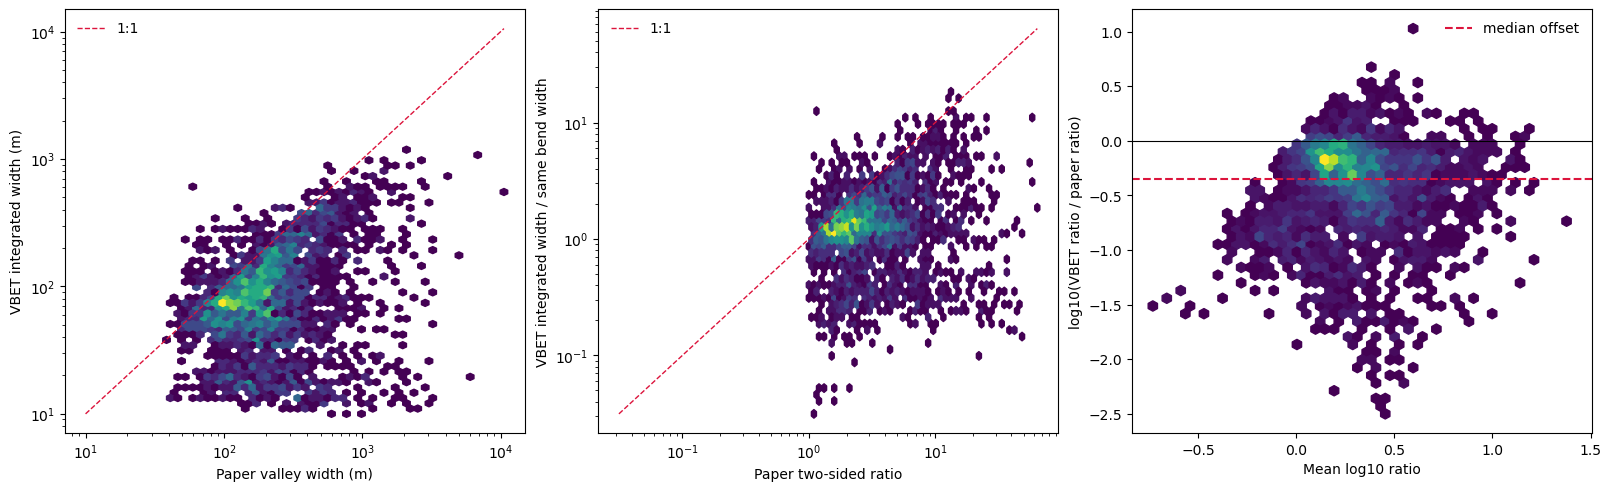

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

def scatter_1to1(ax, x_column, y_column, x_label, y_label):
    x = analysis[x_column]
    y = analysis[y_column]
    ax.hexbin(x, y, xscale='log', yscale='log', gridsize=45, mincnt=1, cmap='viridis')
    lower, upper = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lower, upper], [lower, upper], '--', color='crimson', lw=1, label='1:1')
    ax.set(xscale='log', yscale='log', xlabel=x_label, ylabel=y_label)
    ax.legend(frameon=False)

scatter_1to1(axes[0], 'paper_valley_width_m', 'vbet_integrated_width_m', 'Paper valley width (m)', 'VBET integrated width (m)')
scatter_1to1(axes[1], 'paper_ratio', 'vbet_ratio', 'Paper two-sided ratio', 'VBET integrated width / same bend width')

mean_log = (np.log10(analysis['paper_ratio']) + np.log10(analysis['vbet_ratio'])) / 2
difference_log = np.log10(analysis['vbet_ratio']) - np.log10(analysis['paper_ratio'])
axes[2].hexbin(mean_log, difference_log, gridsize=45, mincnt=1, cmap='viridis')
axes[2].axhline(np.median(difference_log), color='crimson', ls='--', label='median offset')
axes[2].axhline(0, color='black', lw=.8)
axes[2].set(xlabel='Mean log10 ratio', ylabel='log10(VBET ratio / paper ratio)')
axes[2].legend(frameon=False)
plt.show()

## Interpreting a systematic offset

A consistent VBET/paper factor is acceptable for validating a relative classification **if** the rank correlation is strong, the log-log slope is near one, and the difference plot has no systematic trend with magnitude. In that case the products differ mainly in calibration/definition of valley width, and a constant recalibration would align them.

It is not acceptable to dismiss an offset if the paper claims absolute physical valley width, if the offset changes strongly with river size or confinement, or if it changes the relative ordering near class boundaries. The notebook therefore reports offset, slope, spread, and threshold sensitivity rather than relying on correlation alone.

In [36]:
# Sensitivity to centroid-to-bend matching distance.
sensitivity = []
for distance in (100, 150, 200, 250):
    candidate = all_matches.loc[all_matches['match_distance_m'] <= distance].copy()
    candidate = candidate.groupby('bendID', as_index=False).agg(
        combined_reach_id=('combined_reach_id', 'first'),
        n_vbet_dgos=('dgoid', 'size'),
        paper_inner_ratio=('ER_inn', 'first'),
        paper_outer_ratio=('ER_out', 'first'),
        bendDistOut=('bendDistOut', 'first'),
        vbet_integrated_width_m=('integrated_width', 'median'))
    candidate = candidate.merge(paper_bend_widths, on=['combined_reach_id', 'bendDistOut'], how='left', validate='many_to_one')
    candidate['paper_ratio'] = candidate['paper_inner_ratio'] + candidate['paper_outer_ratio']
    candidate['vbet_ratio'] = candidate['vbet_integrated_width_m'] / candidate['bendWidths']
    candidate = candidate.loc[(candidate['n_vbet_dgos'] >= MIN_DGOS_PER_BEND) &
                              np.isfinite(candidate[['paper_ratio', 'vbet_ratio']]).all(axis=1) &
                              (candidate[['paper_ratio', 'vbet_ratio']] > 0).all(axis=1)]
    row = paired_diagnostics(candidate, 'paper_ratio', 'vbet_ratio')
    row['match_distance_m'] = distance
    sensitivity.append(row)
pd.DataFrame(sensitivity).set_index('match_distance_m')

,n_bends,spearman_rho,spearman_p,Theil_Sen_log_slope,Theil_Sen_slope_95_low,Theil_Sen_slope_95_high,median_log10_VBET_over_paper,median_VBET_over_paper_factor,log10_difference_IQR
match_distance_m,,,,,,,,,
100.0,2317.0,0.257539,2.028189e-36,0.283352,0.243359,0.323780,-0.259900,0.549667,0.394672
150.0,2740.0,0.185848,1.026344e-22,0.223613,0.182128,0.265631,-0.351177,0.445474,0.561654
200.0,3024.0,0.181556,8.005553e-24,0.228914,0.186677,0.271795,-0.455011,0.350743,0.671826
250.0,3261.0,0.183184,5.296319e-26,0.232154,0.190534,0.274585,-0.596006,0.253509,0.739457


## Height-factor sensitivity: 1.5 and 3.0

The recalculations use the original cross-sectional profiles and per-bend `conFactor`. Factor 2.0 was recomputed as a check and reproduces the stored paper ratios exactly. The same matching and minimum-DGO rules are applied below.

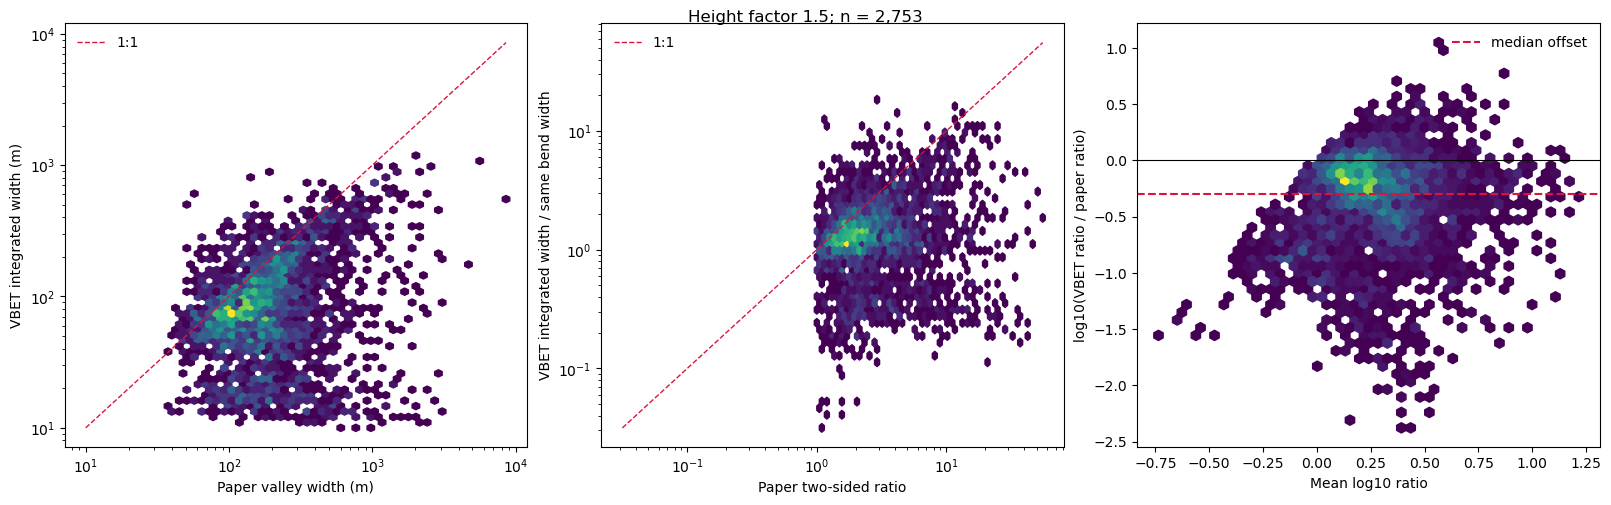

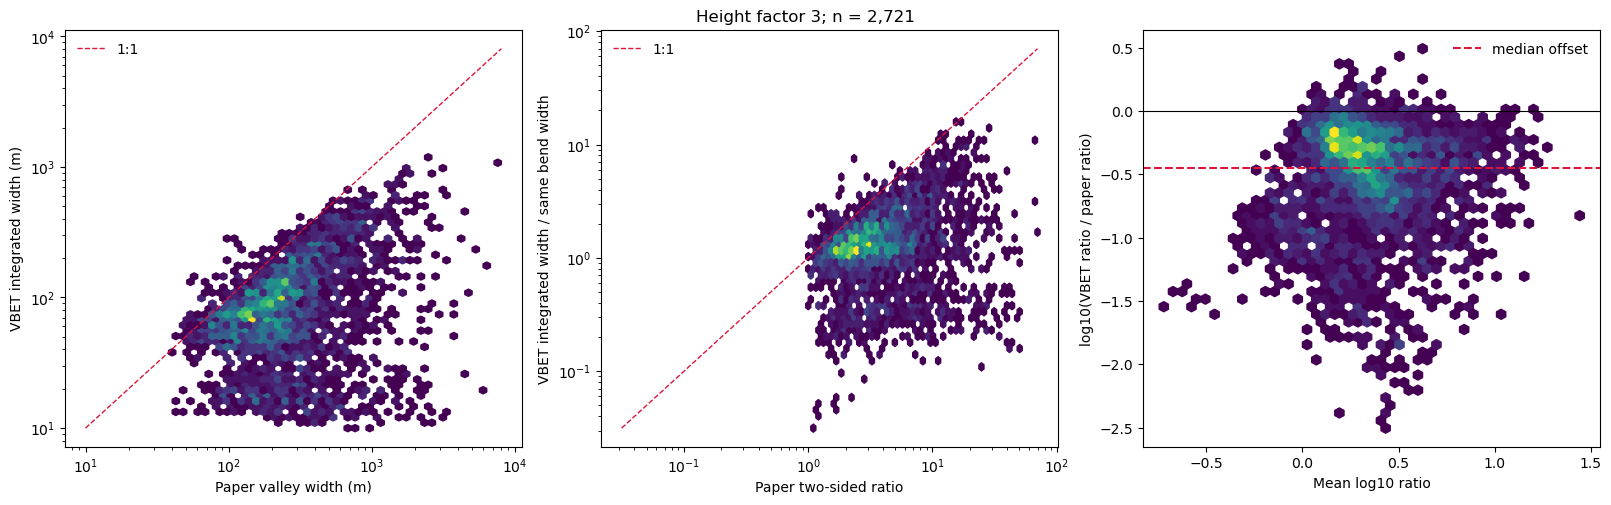

In [37]:
HEIGHT_FACTOR_RESULTS = REPO / 'results/vbet_validation/pnw_bend_height_factor_sensitivity.parquet'
assert HEIGHT_FACTOR_RESULTS.exists(), 'Run pipeline.compute_vbet_height_factor_sensitivity first.'
factor_results = pd.read_parquet(HEIGHT_FACTOR_RESULTS)

def factor_analysis(height_factor):
    paper_ratio = f'paper_ratio_h{height_factor:g}'
    paper_width = f'paper_valley_width_h{height_factor:g}_m'
    columns = [paper_ratio, paper_width, 'vbet_ratio', 'vbet_integrated_width_m']
    frame = factor_results.loc[(factor_results['n_vbet_dgos'] >= MIN_DGOS_PER_BEND) &
                               np.isfinite(factor_results[columns]).all(axis=1) &
                               (factor_results[columns] > 0).all(axis=1)].copy()
    frame['paper_ratio'] = frame[paper_ratio]
    frame['paper_valley_width_m'] = frame[paper_width]
    frame['log10_vbet_over_paper'] = np.log10(frame['vbet_ratio'] / frame['paper_ratio'])
    return frame

def plot_factor_panels(height_factor):
    frame = factor_analysis(height_factor)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
    for ax, x_column, y_column, x_label, y_label in [
        (axes[0], 'paper_valley_width_m', 'vbet_integrated_width_m', 'Paper valley width (m)', 'VBET integrated width (m)'),
        (axes[1], 'paper_ratio', 'vbet_ratio', 'Paper two-sided ratio', 'VBET integrated width / same bend width'),
    ]:
        x, y = frame[x_column], frame[y_column]
        ax.hexbin(x, y, xscale='log', yscale='log', gridsize=45, mincnt=1, cmap='viridis')
        lower, upper = min(x.min(), y.min()), max(x.max(), y.max())
        ax.plot([lower, upper], [lower, upper], '--', color='crimson', lw=1, label='1:1')
        ax.set(xscale='log', yscale='log', xlabel=x_label, ylabel=y_label)
        ax.legend(frameon=False)
    mean_log = (np.log10(frame['paper_ratio']) + np.log10(frame['vbet_ratio'])) / 2
    axes[2].hexbin(mean_log, frame['log10_vbet_over_paper'], gridsize=45, mincnt=1, cmap='viridis')
    axes[2].axhline(frame['log10_vbet_over_paper'].median(), color='crimson', ls='--', label='median offset')
    axes[2].axhline(0, color='black', lw=.8)
    axes[2].set(xlabel='Mean log10 ratio', ylabel='log10(VBET ratio / paper ratio)')
    axes[2].legend(frameon=False)
    fig.suptitle(f'Height factor {height_factor:g}; n = {len(frame):,}', y=1.02)
    plt.show()
    return frame

factor_15 = plot_factor_panels(1.5)
factor_3 = plot_factor_panels(3.0)

## What covaries with the VBET-paper difference?

The error is `log10(VBET ratio / paper ratio)`: negative values mean the paper estimate is wider. These are exploratory associations, not evidence of causation. `n_chan_max` is the available SWORD channel-count proxy; it is not a direct braiding classification.

In [38]:
covariates = {
    'SWORD bend width': 'bendWidths',
    'VBET integrated width': 'vbet_integrated_width_m',
    'VBET channel width': 'vbet_channel_width_m',
    'SWORD maximum channel count': 'n_chan_max',
    'Water-surface elevation': 'wse',
    'Channel slope': 'slope',
    'Drainage area': 'facc',
    'Width ratio': 'widthRatio',
    'Confinement-height coefficient': 'conFactor',
}
correlation_rows = []
for height_factor in (1.5, 2.0, 3.0):
    frame = factor_analysis(height_factor)
    for label, column in covariates.items():
        valid = np.isfinite(frame[column]) & np.isfinite(frame['log10_vbet_over_paper'])
        rho, p_value = stats.spearmanr(frame.loc[valid, column], frame.loc[valid, 'log10_vbet_over_paper'])
        correlation_rows.append({'height_factor': height_factor, 'covariate': label, 'n': valid.sum(), 'Spearman rho': rho, 'p': p_value})
correlations = pd.DataFrame(correlation_rows)
correlations.pivot(index='covariate', columns='height_factor', values='Spearman rho').sort_values(2.0)

height_factor,1.5,2.0,3.0
covariate,,,
Confinement-height coefficient,-0.113249,-0.119547,-0.110900
Channel slope,-0.105325,-0.078221,-0.031503
Width ratio,-0.014585,-0.010633,-0.005125
SWORD maximum channel count,0.004767,-0.001774,-0.000480
Water-surface elevation,0.093052,0.116704,0.165453
SWORD bend width,0.113233,0.119583,0.111026
Drainage area,0.120123,0.147005,0.182869
VBET channel width,0.647654,0.641187,0.629972
VBET integrated width,0.695092,0.653999,0.605731


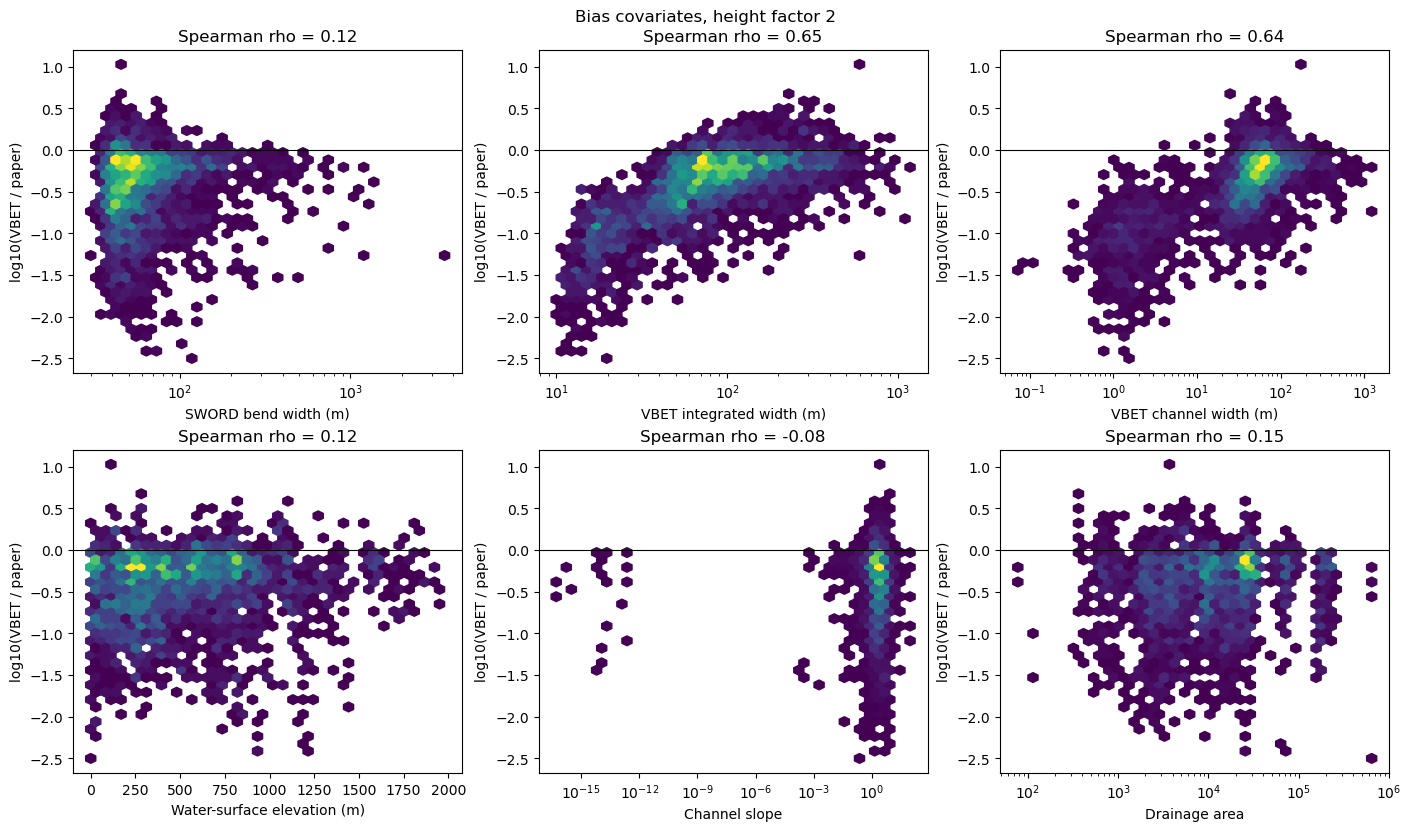

,size,median,mean,std
channel_group,,,,
maximum count = 1,1396,-0.361374,-0.454649,0.436689
maximum count > 1,1344,-0.335169,-0.484042,0.480776


In [39]:
# Visual exploration for the default manuscript factor. Change this to 1.5 or 3.0 as needed.
PATTERN_FACTOR = 2.0
pattern = factor_analysis(PATTERN_FACTOR)
panels = [
    ('bendWidths', 'SWORD bend width (m)', True),
    ('vbet_integrated_width_m', 'VBET integrated width (m)', True),
    ('vbet_channel_width_m', 'VBET channel width (m)', True),
    ('wse', 'Water-surface elevation (m)', False),
    ('slope', 'Channel slope', True),
    ('facc', 'Drainage area', True),
]
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
for ax, (column, label, log_x) in zip(axes.flat, panels):
    valid = np.isfinite(pattern[column]) & np.isfinite(pattern['log10_vbet_over_paper']) & (pattern[column] > 0 if log_x else True)
    x = pattern.loc[valid, column]
    y = pattern.loc[valid, 'log10_vbet_over_paper']
    ax.hexbin(x, y, xscale='log' if log_x else 'linear', gridsize=35, mincnt=1, cmap='viridis')
    rho = stats.spearmanr(x, y).statistic
    ax.axhline(0, color='black', lw=.8)
    ax.set(xlabel=label, ylabel='log10(VBET / paper)', title=f'Spearman rho = {rho:.2f}')
fig.suptitle(f'Bias covariates, height factor {PATTERN_FACTOR:g}', y=1.02)
plt.show()

# Channel-count comparison, kept separate because it is categorical.
channel_groups = pattern.assign(channel_group=np.where(pattern['n_chan_max'] > 1, 'maximum count > 1', 'maximum count = 1'))
channel_groups.groupby('channel_group')['log10_vbet_over_paper'].agg(['size', 'median', 'mean', 'std'])

## Crosswalk diagnostic: does VBET-to-SWORD matching distance matter?

This is a necessary quality check. The Riverscapes export supplies DGO centroids, not a shared SWORD identifier or DGO polygons. A distant centroid can represent a neighbouring tributary or another part of the valley, particularly near confluences. If the error becomes systematically more negative with distance, the matching rule is contributing to the apparent VBET-paper disagreement.

Spearman rho between median match distance and log10(VBET/paper): -0.459


,n,median_distance_m,median_log10_vbet_over_paper,median_VBET_over_paper_factor
distance_quartile,,,,
"(1.582, 40.598]",685,28.337604,-0.158742,0.693838
"(40.598, 60.593]",685,50.983767,-0.309751,0.490060
"(60.593, 81.142]",685,70.164351,-0.517898,0.303460
"(81.142, 145.277]",685,96.310236,-0.644092,0.226938


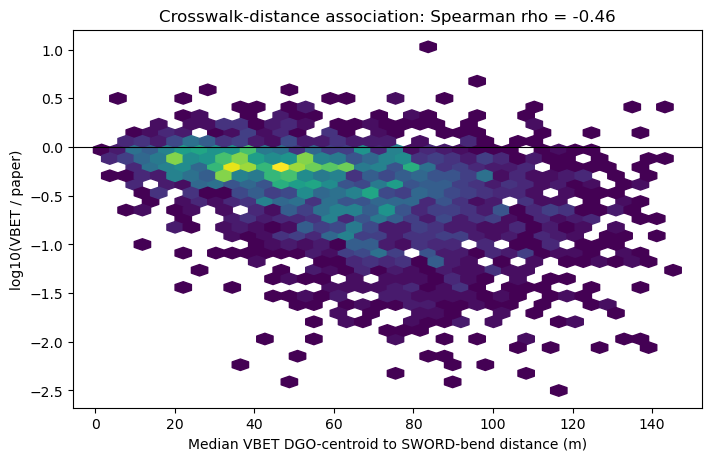

In [40]:
match_quality = (all_matches.loc[all_matches['match_distance_m'] <= MATCH_DISTANCE_M]
                 .groupby('bendID', as_index=False)
                 .agg(min_match_distance_m=('match_distance_m', 'min'),
                      median_match_distance_m=('match_distance_m', 'median'),
                      n_dgos_at_threshold=('dgoid', 'size')))
crosswalk = factor_analysis(2.0).merge(match_quality, on='bendID', how='left', validate='one_to_one')
rho = stats.spearmanr(crosswalk['median_match_distance_m'], crosswalk['log10_vbet_over_paper']).statistic
print(f'Spearman rho between median match distance and log10(VBET/paper): {rho:.3f}')

crosswalk['distance_quartile'] = pd.qcut(crosswalk['median_match_distance_m'], 4, duplicates='drop')
distance_summary = crosswalk.groupby('distance_quartile', observed=True).agg(
    n=('bendID', 'size'),
    median_distance_m=('median_match_distance_m', 'median'),
    median_log10_vbet_over_paper=('log10_vbet_over_paper', 'median'),
)
distance_summary['median_VBET_over_paper_factor'] = 10 ** distance_summary['median_log10_vbet_over_paper']
display(distance_summary)

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.hexbin(crosswalk['median_match_distance_m'], crosswalk['log10_vbet_over_paper'], gridsize=35, mincnt=1, cmap='viridis')
ax.axhline(0, color='black', lw=.8)
ax.set(xlabel='Median VBET DGO-centroid to SWORD-bend distance (m)', ylabel='log10(VBET / paper)', title=f'Crosswalk-distance association: Spearman rho = {rho:.2f}')
plt.show()

## Prototype refined crosswalk

The refined procedure starts from the same 150 m candidate set, groups DGOs by `level_path`, then selects the path with the closest VBET-channel-width to the SWORD bend width. `fcode` only resolves otherwise similar candidates and is retained as a quality flag. This is a diagnostic prototype: it must be visually audited before becoming the final matching rule.

In [41]:
REFINED_MATCHES = REPO / 'results/vbet_validation/pnw_refined_vbet_level_path_matches.parquet'
assert REFINED_MATCHES.exists(), 'Run pipeline.refine_vbet_candidate_matches first.'
refined = pd.read_parquet(REFINED_MATCHES)
refined_comparison = factor_analysis(2.0).merge(
    refined[['bendID', 'level_path', 'dgoids', 'fcodes', 'n_dgos_on_level_path', 'n_candidate_level_paths',
             'vbet_integrated_width_m', 'vbet_channel_width_m', 'channel_width_ratio_to_sword',
             'channel_width_compatibility', 'median_match_distance_m', 'width_score_separation']],
    on='bendID', how='inner', suffixes=('_coarse', '_refined'), validate='one_to_one'
)
refined_comparison['vbet_ratio_refined'] = refined_comparison['vbet_integrated_width_m_refined'] / refined_comparison['bendWidths']
refined_comparison['log10_refined_vbet_over_paper'] = np.log10(refined_comparison['vbet_ratio_refined'] / refined_comparison['paper_ratio'])

def match_summary(vbet_ratio_column, error_column):
    valid = np.isfinite(refined_comparison[[vbet_ratio_column, 'paper_ratio', error_column]]).all(axis=1) & (refined_comparison[[vbet_ratio_column, 'paper_ratio']] > 0).all(axis=1)
    frame = refined_comparison.loc[valid]
    error = frame[error_column]
    return pd.Series({
        'n': len(frame),
        'Spearman ratio correlation': stats.spearmanr(np.log10(frame[vbet_ratio_column]), np.log10(frame['paper_ratio'])).statistic,
        'median VBET/paper factor': 10 ** error.median(),
        'paper wider (%)': 100 * (error < 0).mean(),
        'within factor 2 (%)': 100 * (np.abs(error) <= np.log10(2)).mean(),
    })

pd.DataFrame({
    'coarse: median all DGOs within 150 m': match_summary('vbet_ratio', 'log10_vbet_over_paper'),
    'refined: width-compatible level path': match_summary('vbet_ratio_refined', 'log10_refined_vbet_over_paper'),
}).T

,n,Spearman ratio correlation,median VBET/paper factor,paper wider (%),within factor 2 (%)
coarse: median all DGOs within 150 m,2740.0,0.185848,0.445474,92.043796,43.941606
refined: width-compatible level path,2740.0,0.396005,0.620154,86.642336,62.043796


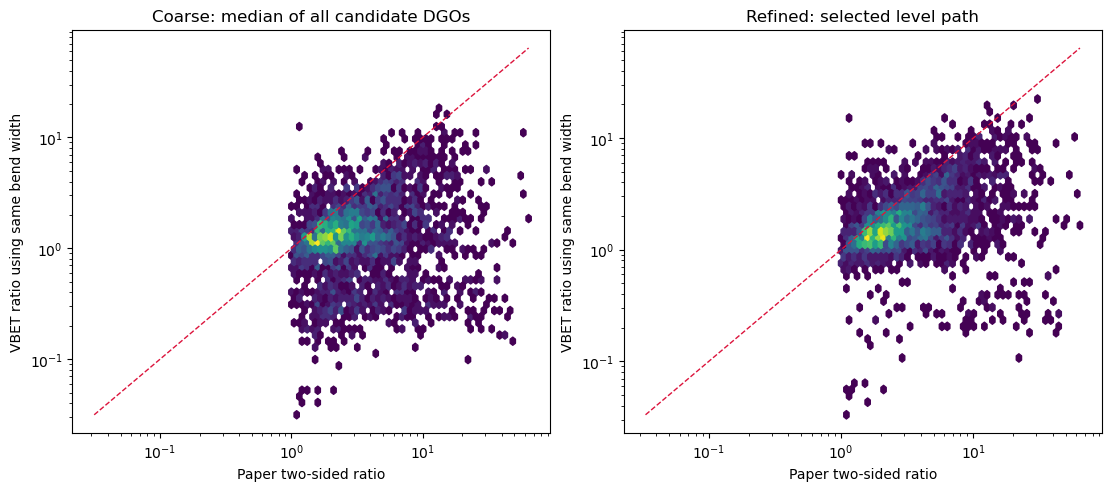

count    2740.000000
mean        2.216709
std         3.299799
min         0.213796
10%         1.000000
25%         1.000000
50%         1.086518
75%         1.629592
90%         4.827959
95%         7.580795
max        56.889856
Name: selected_vbet_width_change, dtype: float64

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
for ax, ratio_column, title in [
    (axes[0], 'vbet_ratio', 'Coarse: median of all candidate DGOs'),
    (axes[1], 'vbet_ratio_refined', 'Refined: selected level path'),
]:
    valid = np.isfinite(refined_comparison[[ratio_column, 'paper_ratio']]).all(axis=1) & (refined_comparison[[ratio_column, 'paper_ratio']] > 0).all(axis=1)
    x, y = refined_comparison.loc[valid, 'paper_ratio'], refined_comparison.loc[valid, ratio_column]
    ax.hexbin(x, y, xscale='log', yscale='log', gridsize=45, mincnt=1, cmap='viridis')
    lower, upper = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lower, upper], [lower, upper], '--', color='crimson', lw=1)
    ax.set(xscale='log', yscale='log', xlabel='Paper two-sided ratio', ylabel='VBET ratio using same bend width', title=title)
plt.show()

refined_comparison['selected_vbet_width_change'] = refined_comparison['vbet_integrated_width_m_refined'] / refined_comparison['vbet_integrated_width_m_coarse']
refined_comparison['selected_vbet_width_change'].describe(percentiles=[.1, .25, .5, .75, .9, .95])

## Midwest Report: a separate regional comparison

The Midwest AOI is a second Riverscapes Report extract from the same 2025-CONUS RME source family. The same 150-m candidate generation and pre-specified 0.5–2 VBET-channel/SWORD-bend-width crosswalk screen are applied here. PNW and Midwest are pooled for the primary regional validation result below; their separate summaries diagnose geographic heterogeneity and are not used to exclude either region.

As throughout this notebook, the channel-width screen establishes a likely river identity and is not based on the VBET integrated width being compared below. Nevertheless, interpretation remains conditional on that screen.

,strict paired bends,Spearman rho,median VBET / paper,within factor 2,multi-path share,median selected-path distance (m)
region,,,,,,
PNW,3501,0.597,0.648,64.5%,58.0%,47.9
Midwest,875,0.218,0.636,54.2%,21.7%,66.8


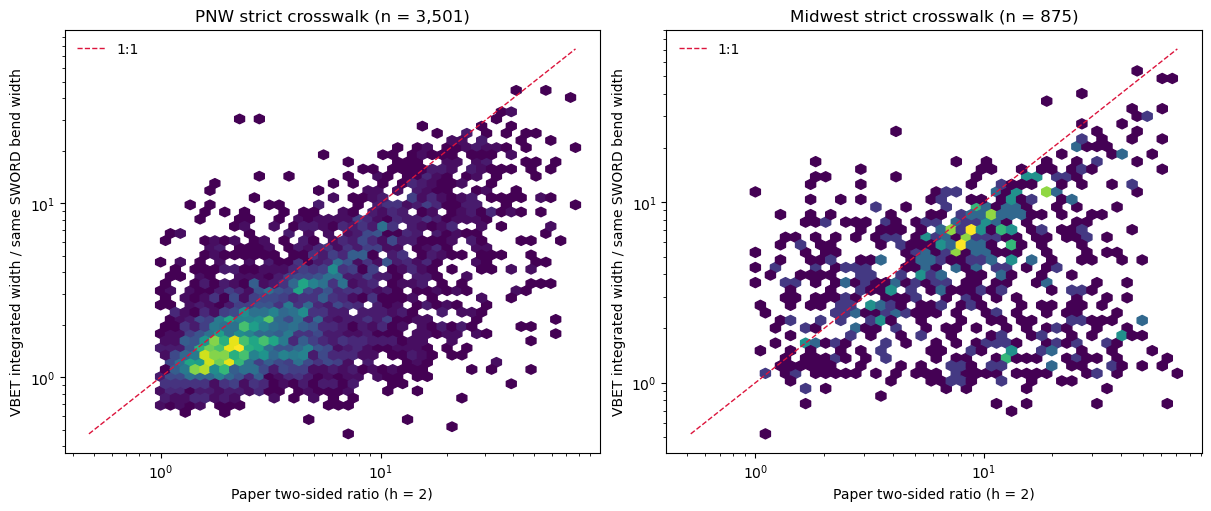

In [43]:
REGIONAL_FILES = {
    'PNW': {
        'refined': REPO / 'results/vbet_validation/pnw_refined_vbet_level_path_matches.parquet',
        'height': REPO / 'results/vbet_validation/pnw_bend_height_factor_sensitivity.parquet',
    },
    'Midwest': {
        'refined': REPO / 'results/vbet_validation/midwest_refined_vbet_level_path_matches.parquet',
        'height': REPO / 'results/vbet_validation/midwest_bend_height_factor_sensitivity.parquet',
    },
}

def refined_region_pairs(paths):
    refined = pd.read_parquet(paths['refined'])
    height = pd.read_parquet(paths['height'])[['bendID', 'paper_ratio_h2']]
    paired = refined.merge(height, on='bendID', how='inner', validate='one_to_one').copy()
    paired['vbet_ratio_refined'] = paired['vbet_integrated_width_m'] / paired['bendWidths']
    valid = (
        paired['accepted_high_confidence']
        & np.isfinite(paired[['paper_ratio_h2', 'vbet_ratio_refined']]).all(axis=1)
        & (paired[['paper_ratio_h2', 'vbet_ratio_refined']] > 0).all(axis=1)
    )
    return paired.loc[valid].copy()

regional_pairs = {region: refined_region_pairs(paths) for region, paths in REGIONAL_FILES.items()}
regional_summary = []
for region, paired in regional_pairs.items():
    factor = paired['vbet_ratio_refined'] / paired['paper_ratio_h2']
    regional_summary.append({
        'region': region,
        'strict paired bends': len(paired),
        'Spearman rho': stats.spearmanr(paired['paper_ratio_h2'], paired['vbet_ratio_refined']).statistic,
        'median VBET / paper': factor.median(),
        'within factor 2': factor.between(0.5, 2.0).mean(),
        'multi-path share': (paired['n_candidate_level_paths'] > 1).mean(),
        'median selected-path distance (m)': paired['median_match_distance_m'].median(),
    })
regional_summary = pd.DataFrame(regional_summary).set_index('region')
display(regional_summary.style.format({
    'Spearman rho': '{:.3f}', 'median VBET / paper': '{:.3f}',
    'within factor 2': '{:.1%}', 'multi-path share': '{:.1%}',
    'median selected-path distance (m)': '{:.1f}',
}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, (region, paired) in zip(axes, regional_pairs.items()):
    x, y = paired['paper_ratio_h2'], paired['vbet_ratio_refined']
    ax.hexbin(x, y, xscale='log', yscale='log', gridsize=42, mincnt=1, cmap='viridis')
    lower, upper = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lower, upper], [lower, upper], '--', color='crimson', lw=1, label='1:1')
    ax.set(
        xscale='log', yscale='log',
        xlabel='Paper two-sided ratio (h = 2)',
        ylabel='VBET integrated width / same SWORD bend width',
        title=f'{region} strict crosswalk (n = {len(paired):,})',
    )
    ax.legend(frameon=False, loc='upper left')
plt.show()

## Pooled primary result and offset investigation

The primary regional result pools every valid, strict-screened pair from both AOIs. Region remains visible in every diagnostic and is not used as an exclusion.

The residual is `log10(VBET integrated width / paper valley width)`. Correlating that residual with either of its two component widths is mathematically coupled, so those correlations are not interpreted as causes. Instead, the raw-width panel quantifies their scaling relation; residual panels use distance, SWORD bend width, slope, drainage proxy, channel count, and crosswalk complexity.

In [44]:
from scipy.stats import theilslopes

# Add manuscript covariates only after defining the strict paired sample.
# They are diagnostics, not additional selection criteria.
covariate_candidates = ['bendID', 'combined_reach_id', 'n_chan_max', 'slope', 'facc', 'wse', 'strm_order', 'networkGroup']
for region, paths in REGIONAL_FILES.items():
    height = pd.read_parquet(paths['height'])
    covariates = height[[column for column in covariate_candidates if column in height]].drop_duplicates('bendID')
    regional_pairs[region] = regional_pairs[region].merge(covariates, on='bendID', how='left', validate='one_to_one')

pooled_pairs = pd.concat(regional_pairs.values(), ignore_index=True)
pooled_pairs['paper_valley_width_m'] = pooled_pairs['paper_ratio_h2'] * pooled_pairs['bendWidths']
pooled_pairs['log10_vbet_over_paper'] = np.log10(
    pooled_pairs['vbet_integrated_width_m'] / pooled_pairs['paper_valley_width_m']
)

def summary_row(label, frame):
    factor = 10 ** frame['log10_vbet_over_paper']
    return {
        'sample': label,
        'paired bends': len(frame),
        'Spearman rho': stats.spearmanr(frame['paper_ratio_h2'], frame['vbet_ratio_refined']).statistic,
        'median VBET / paper': factor.median(),
        'within factor 2': factor.between(0.5, 2.0).mean(),
        'median offset (log10)': frame['log10_vbet_over_paper'].median(),
    }

primary_summary = pd.DataFrame([
    summary_row('Pooled PNW + Midwest', pooled_pairs),
    *[summary_row(region, frame) for region, frame in regional_pairs.items()],
]).set_index('sample')
display(primary_summary.style.format({
    'Spearman rho': '{:.3f}', 'median VBET / paper': '{:.3f}',
    'within factor 2': '{:.1%}', 'median offset (log10)': '{:.3f}',
}))

# Raw widths, rather than residual-versus-component-width correlations.
scaling_rows = []
for label, frame in [('Pooled PNW + Midwest', pooled_pairs), *regional_pairs.items()]:
    x = np.log10(frame['paper_valley_width_m'])
    y = np.log10(frame['vbet_integrated_width_m'])
    slope, intercept, lower, upper = theilslopes(y, x)
    scaling_rows.append({
        'sample': label, 'Spearman width rho': stats.spearmanr(x, y).statistic,
        'Theil–Sen log-log slope': slope, 'slope CI low': lower, 'slope CI high': upper,
    })
display(pd.DataFrame(scaling_rows).set_index('sample').style.format('{:.3f}'))

diagnostic_columns = {
    'median_match_distance_m': 'Selected-path median centroid distance (m)',
    'bendWidths': 'SWORD bend width (m)',
    'slope': 'SWORD slope',
    'facc': 'SWORD flow accumulation',
    'n_chan_max': 'Maximum mapped channel count',
    'n_dgos_on_level_path': 'VBET DGOs on selected path',
    'n_candidate_level_paths': 'Candidate VBET level paths',
}
correlations = []
for column, label in diagnostic_columns.items():
    for sample, frame in [('Pooled', pooled_pairs), *regional_pairs.items()]:
        valid = frame[[column, 'log10_vbet_over_paper']].dropna()
        correlations.append({
            'variable': label, 'sample': sample, 'n': len(valid),
            'residual Spearman rho': stats.spearmanr(valid[column], valid['log10_vbet_over_paper']).statistic,
        })
offset_correlations = pd.DataFrame(correlations)
display(offset_correlations.pivot(index='variable', columns='sample', values='residual Spearman rho').style.format('{:.3f}'))

def binned_median(ax, frame, x_column, label, log_x=False):
    values = frame[[x_column, 'log10_vbet_over_paper']].dropna().copy()
    values = values.loc[np.isfinite(values).all(axis=1)]
    if log_x:
        values = values.loc[values[x_column] > 0].copy()
        x_for_bins = np.log10(values[x_column])
    else:
        x_for_bins = values[x_column]
    values['bin'] = pd.qcut(x_for_bins, q=10, duplicates='drop')
    grouped = values.groupby('bin', observed=True)
    x = grouped[x_column].median()
    y = grouped['log10_vbet_over_paper'].median()
    ax.plot(x, y, marker='o', color='black', lw=1.5)
    ax.axhline(0, color='0.4', lw=0.8)
    if log_x: ax.set_xscale('log')
    ax.set(xlabel=label, ylabel='median log10(VBET / paper)')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for region, frame in regional_pairs.items():
    axes[0].scatter(frame['paper_valley_width_m'], frame['vbet_integrated_width_m'],
                    s=5, alpha=.22, label=region)
axes[0].plot([1, 1e5], [1, 1e5], '--', color='crimson', lw=1)
axes[0].set(xscale='log', yscale='log', xlim=(1, 1e5), ylim=(1, 1e5),
            xlabel='Paper valley width (m)', ylabel='VBET integrated width (m)')
axes[0].legend(frameon=False)
binned_median(axes[1], pooled_pairs, 'median_match_distance_m', 'Selected-path centroid distance (m)')
binned_median(axes[2], pooled_pairs, 'bendWidths', 'SWORD bend width (m)', log_x=True)
plt.show()

KeyError: 'log10_vbet_over_paper'

## Where are the large disagreements?

Overall correlation can conceal a small number of systematic mismatch regimes. The tables below therefore describe the tails of the *outcome* comparison without using these variables to select matches. They identify associations, not causes: paper valley width and VBET integrated width are mechanically related to the plotted residual and should be interpreted only as scale diagnostics.

The most useful candidates for a causal explanation are crosswalk distance, SWORD bend width, VBET slope, flow accumulation, and channel count. These help distinguish potential correspondence error from differing treatment of wide, low-gradient, or multi-channel valley bottoms.

In [ ]:
# VBET / paper valley-width factor.  Matching was screened using channel width,
# not this integrated valley-width outcome.
d = pooled_pairs.copy()
d['width_factor'] = d['vbet_integrated_width_m'] / d['paper_valley_width_h2_m']
d['offset_group'] = pd.cut(
    d['width_factor'], [0, .2, .5, 2, 5, np.inf],
    labels=['VBET <0.2× paper', 'VBET 0.2–0.5× paper', 'within factor 2',
            'VBET 2–5× paper', 'VBET >5× paper']
)

tail_cols = ['median_match_distance_m', 'bendWidths', 'paper_valley_width_h2_m',
             'vbet_integrated_width_m', 'slope', 'facc', 'n_chan_max', 'n_candidate_paths']
offset_summary = (d.groupby('offset_group', observed=True)
    .agg(n=('width_factor', 'size'), share=('width_factor', 'size'),
         median_factor=('width_factor', 'median'), PNW_share=('region', lambda x: (x == 'PNW').mean()),
         **{f'median_{c}': (c, 'median') for c in tail_cols})
    .reset_index())
offset_summary['share'] = offset_summary['share'] / len(d)
display(offset_summary.style.format({'share': '{:.1%}', 'PNW_share': '{:.1%}', 'median_factor': '{:.3f}'}))

# A monotonic correlation can miss tail enrichment. Quantile tables directly ask
# whether the most severe VBET underestimates concentrate in variable groups.
def tail_by_quantile(frame, variable, q=10):
    x = frame[[variable, 'width_factor']].dropna().copy()
    x['bin'] = pd.qcut(x[variable], q=q, duplicates='drop')
    return (x.groupby('bin', observed=True)
             .agg(n=(variable, 'size'), median_value=(variable, 'median'),
                  median_factor=('width_factor', 'median'),
                  share_VBET_lt_0p2=('width_factor', lambda z: (z < .2).mean()),
                  share_within_factor_2=('width_factor', lambda z: ((z >= .5) & (z <= 2)).mean()))
             .reset_index(drop=True))

for variable in ['median_match_distance_m', 'bendWidths', 'slope', 'facc']:
    print(f'\n{variable}')
    display(tail_by_quantile(d, variable).style.format({
        'median_value': '{:.2f}', 'median_factor': '{:.3f}',
        'share_VBET_lt_0p2': '{:.1%}', 'share_within_factor_2': '{:.1%}'}))

# Small multiples make non-monotonic tail patterns explicit.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
for ax, variable, label in zip(axes,
                               ['median_match_distance_m', 'bendWidths', 'slope'],
                               ['Selected-path distance (m)', 'SWORD bend width (m)', 'VBET slope']):
    t = tail_by_quantile(d, variable)
    ax.plot(t['median_value'], t['share_VBET_lt_0p2'], 'o-', color='#5b1a76')
    ax.set(xlabel=label, ylabel='Share VBET <0.2× paper', ylim=(0, max(.28, t['share_VBET_lt_0p2'].max() * 1.15)))
    if variable in ['median_match_distance_m', 'bendWidths']:
        ax.set_xscale('log')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.show()

## Spatial-dependence sensitivity

Adjacent bends on one paper **combined reach** are not independent observations. `combined_reach_id` is the analysis reach identifier created by merging connected short input reaches; it is not necessarily an original SWORD `reach_id`. The bend-level statistic remains the primary comparison, but this sensitivity collapses all bends within each `combined_reach_id` to their median ratio before calculating Spearman correlation. A 1,000-replicate cluster bootstrap samples whole combined reaches. The level-path summary is an additional, more coarse VBET-network sensitivity check; it is not a substitute for the bend-level comparison because it collapses different lengths and numbers of bends.

In [ ]:
# Region prefixes prevent coincident numeric IDs in the two AOIs being combined.
dependence = pooled_pairs.copy()
dependence['reach_key'] = dependence['region'] + '_' + dependence['combined_reach_id'].astype('Int64').astype(str)
dependence['path_key'] = dependence['region'] + '_' + dependence['level_path'].astype(str)

def rank_rho(frame):
    return stats.spearmanr(frame['paper_ratio_h2'], frame['vbet_ratio_refined']).statistic

reach_median = dependence.groupby('reach_key', as_index=False)[['paper_ratio_h2', 'vbet_ratio_refined']].median()
path_median = dependence.groupby('path_key', as_index=False)[['paper_ratio_h2', 'vbet_ratio_refined']].median()
reach_path_median = dependence.groupby(['reach_key', 'path_key'], as_index=False)[['paper_ratio_h2', 'vbet_ratio_refined']].median()

dependence_summary = pd.DataFrame([
    {'analysis unit': 'All strict paired bends', 'n units': len(dependence), 'Spearman rho': rank_rho(dependence)},
    {'analysis unit': 'Median per paper combined reach', 'n units': len(reach_median), 'Spearman rho': rank_rho(reach_median)},
    {'analysis unit': 'Median per VBET level path', 'n units': len(path_median), 'Spearman rho': rank_rho(path_median)},
    {'analysis unit': 'Median per reach × VBET path', 'n units': len(reach_path_median), 'Spearman rho': rank_rho(reach_path_median)},
])
display(dependence_summary.style.format({'Spearman rho': '{:.3f}'}))

# Resample paper combined reaches, not individual bends. This is deliberately
# based on combined-reach medians so that units with many bends cannot dominate a replicate.
rng = np.random.default_rng(20260907)
values = reach_median[['paper_ratio_h2', 'vbet_ratio_refined']].to_numpy()
bootstrap_rho = np.empty(1000)
for i in range(len(bootstrap_rho)):
    sampled = values[rng.integers(0, len(values), len(values))]
    bootstrap_rho[i] = stats.spearmanr(sampled[:, 0], sampled[:, 1]).statistic

print(f'Reach-median bootstrap 95% interval: {np.quantile(bootstrap_rho, .025):.3f} to {np.quantile(bootstrap_rho, .975):.3f}')
plt.figure(figsize=(6, 3.5))
plt.hist(bootstrap_rho, bins=30, color='#5b1a76', alpha=.8)
plt.axvline(rank_rho(reach_median), color='black', lw=1, label='Observed reach-median rho')
plt.xlabel('Cluster-bootstrap Spearman rho')
plt.ylabel('Replicates')
plt.legend(frameon=False)
plt.show()

## Pooled sensitivity to the paper confinement-height factor

The manuscript ratio is recalculated from the original profiles at height factors 1.5, 2.0 (primary), and 3.0. VBET width and the crosswalk are held fixed. This is a sensitivity analysis of whether convergent rank agreement depends on the paper's terrain-height setting; it is not a re-selection of matches. Results are shown both with each factor's available profiles and on the common complete-case sample.

In [ ]:
factor_columns = ['paper_ratio_h1.5', 'paper_ratio_h2', 'paper_ratio_h3']
strict_factor_parts = []
for region, paths in REGIONAL_FILES.items():
    refined = pd.read_parquet(paths['refined'])
    heights = pd.read_parquet(paths['height'])[['bendID', *factor_columns]]
    part = refined.merge(heights, on='bendID', how='inner', validate='one_to_one')
    part['vbet_ratio_refined'] = part['vbet_integrated_width_m'] / part['bendWidths']
    valid_vbet = np.isfinite(part['vbet_ratio_refined']) & (part['vbet_ratio_refined'] > 0)
    part = part.loc[part['accepted_high_confidence'] & valid_vbet].copy()
    part['region'] = region
    strict_factor_parts.append(part)
strict_factor_pairs = pd.concat(strict_factor_parts, ignore_index=True)

def factor_summary(frame, factor_column, sample):
    x = frame.loc[np.isfinite(frame[factor_column]) & (frame[factor_column] > 0)].copy()
    width_factor = x['vbet_ratio_refined'] / x[factor_column]
    return {'sample': sample, 'paper height factor': factor_column.removeprefix('paper_ratio_h'),
            'n': len(x), 'Spearman rho': stats.spearmanr(x[factor_column], x['vbet_ratio_refined']).statistic,
            'median VBET / paper': width_factor.median(),
            'within factor 2': width_factor.between(.5, 2).mean()}

rows = [factor_summary(strict_factor_pairs, column, 'All available profiles') for column in factor_columns]
complete = strict_factor_pairs.loc[np.isfinite(strict_factor_pairs[factor_columns]).all(axis=1)
                                   & (strict_factor_pairs[factor_columns] > 0).all(axis=1)].copy()
rows += [factor_summary(complete, column, 'Common complete-case profiles') for column in factor_columns]
height_sensitivity = pd.DataFrame(rows)
display(height_sensitivity.style.format({'Spearman rho': '{:.3f}',
                                         'median VBET / paper': '{:.3f}',
                                         'within factor 2': '{:.1%}'}))

,sample,paper height factor,n,Spearman rho,median VBET / paper,within factor 2
0,All available profiles,1.5,4427,0.484,0.737,64.4%
1,All available profiles,2,4376,0.564,0.647,62.4%
2,All available profiles,3,4259,0.635,0.509,50.5%
3,Common complete-case profiles,1.5,4259,0.480,0.740,65.4%
4,Common complete-case profiles,2,4259,0.565,0.652,63.3%
5,Common complete-case profiles,3,4259,0.635,0.509,50.5%


## Exploratory check of why agreement changes with the height factor

This is an association check, not evidence that a higher threshold reaches a true valley wall. It tests two narrower predictions: whether the paper-width increase from 1.5 to 3 is concentrated in wide or low-gradient settings, and whether the nearest 1.5-factor intercept is unusually close to the channel in those settings. The latter would be consistent with premature interception of a local feature, but geometry/profile inspection would still be required to identify the feature.

In [ ]:
mechanism_parts = []
profile_columns = ['bendID', 'paper_ratio_h1.5', 'paper_ratio_h3', 'ER_out_h1.5', 'ER_inn_h1.5',
                   'bendWidths', 'slope']
for region, paths in REGIONAL_FILES.items():
    refined = pd.read_parquet(paths['refined'])
    profiles = pd.read_parquet(paths['height'])[profile_columns]
    part = refined.merge(profiles, on='bendID', how='inner', suffixes=('', '_profile'), validate='one_to_one')
    part['vbet_ratio'] = part['vbet_integrated_width_m'] / part['bendWidths']
    valid = part['accepted_high_confidence'] & np.isfinite(part[['paper_ratio_h1.5', 'paper_ratio_h3', 'vbet_ratio']]).all(axis=1)
    valid &= (part[['paper_ratio_h1.5', 'paper_ratio_h3', 'vbet_ratio']] > 0).all(axis=1)
    mechanism_parts.append(part.loc[valid].copy())
mechanism = pd.concat(mechanism_parts, ignore_index=True)
mechanism['log10_growth_h1p5_to_h3'] = np.log10(mechanism['paper_ratio_h3'] / mechanism['paper_ratio_h1.5'])
mechanism['residual_h1p5'] = np.log10(mechanism['vbet_ratio'] / mechanism['paper_ratio_h1.5'])
mechanism['nearest_side_ratio_h1p5'] = mechanism[['ER_out_h1.5', 'ER_inn_h1.5']].min(axis=1)

association_rows = []
for column, label in [('bendWidths_profile', 'SWORD bend width'), ('slope', 'SWORD slope'), ('residual_h1p5', 'VBET/paper residual at h=1.5')]:
    valid = mechanism[[column, 'log10_growth_h1p5_to_h3']].dropna()
    association_rows.append({'variable': label, 'n': len(valid),
                             'Spearman with log10(h3 / h1.5 paper width)':
                             stats.spearmanr(valid[column], valid['log10_growth_h1p5_to_h3']).statistic})
display(pd.DataFrame(association_rows).style.format({'Spearman with log10(h3 / h1.5 paper width)': '{:.3f}'}))

# Compare the groups implicated by the outcome diagnostic with all other bends.
wide = mechanism['bendWidths_profile'] >= mechanism['bendWidths_profile'].quantile(.9)
low_slope = mechanism['slope'] <= mechanism['slope'].quantile(.2)
group_rows = []
for label, mask in [('All common-profile bends', pd.Series(True, index=mechanism.index)),
                    ('Widest bend-width decile', wide),
                    ('Lowest slope quintile', low_slope),
                    ('Wide and low-slope', wide & low_slope)]:
    x = mechanism.loc[mask]
    group_rows.append({'group': label, 'n': len(x),
                       'median h3 / h1.5 paper width': 10 ** x['log10_growth_h1p5_to_h3'].median(),
                       'median nearest-side ratio at h1.5': x['nearest_side_ratio_h1p5'].median(),
                       'share nearest side <= 0.55 bend widths': (x['nearest_side_ratio_h1p5'] <= .55).mean()})
display(pd.DataFrame(group_rows).set_index('group').style.format({
    'median h3 / h1.5 paper width': '{:.3f}', 'median nearest-side ratio at h1.5': '{:.3f}',
    'share nearest side <= 0.55 bend widths': '{:.1%}'}))

## Bend-width distribution sensitivity

The primary result should not be interpreted as being supported only by a particular part of the SWORD bend-width distribution. This check therefore reports correlations after excluding either tail, retaining the middle 80%, and retaining only the tails after removing a broad central band. Width-decile estimates are descriptive because their narrower rank ranges make within-decile correlations less directly comparable with the pooled value.

In [ ]:
width_sensitivity = pooled_pairs.copy()
# qcut handles the empirical distribution; some tied integer widths make bin sizes differ slightly.
width_sensitivity['width_decile'] = pd.qcut(width_sensitivity['bendWidths'], q=10, labels=False, duplicates='drop') + 1

def width_rho_row(label, frame):
    return {'sample': label, 'n bends': len(frame),
            'Spearman rho': stats.spearmanr(frame['paper_ratio_h2'], frame['vbet_ratio_refined']).statistic,
            'minimum bend width (m)': frame['bendWidths'].min(),
            'maximum bend width (m)': frame['bendWidths'].max()}

width_rows = [
    width_rho_row('All strict paired bends', width_sensitivity),
    width_rho_row('Exclude narrowest decile', width_sensitivity.loc[width_sensitivity.width_decile > 1]),
    width_rho_row('Exclude widest decile', width_sensitivity.loc[width_sensitivity.width_decile < 10]),
    width_rho_row('Middle 80% only (deciles 2–9)', width_sensitivity.loc[width_sensitivity.width_decile.between(2, 9)]),
    width_rho_row('Tails only (exclude central 40%; deciles 4–7)', width_sensitivity.loc[~width_sensitivity.width_decile.between(4, 7)]),
    width_rho_row('Exclude central 20% (deciles 5–6)', width_sensitivity.loc[~width_sensitivity.width_decile.between(5, 6)]),
]
display(pd.DataFrame(width_rows).set_index('sample').style.format({
    'Spearman rho': '{:.3f}', 'minimum bend width (m)': '{:.1f}', 'maximum bend width (m)': '{:.1f}'}))

decile_rows = [width_rho_row(f'Decile {decile}', frame)
               for decile, frame in width_sensitivity.groupby('width_decile', observed=True)]
display(pd.DataFrame(decile_rows).set_index('sample').style.format({
    'Spearman rho': '{:.3f}', 'minimum bend width (m)': '{:.1f}', 'maximum bend width (m)': '{:.1f}'}))

## Profile non-intersection diagnostic

A missing two-sided paper ratio does **not** by itself establish that total valley width exceeds a fixed cap. Orthogonal lines are initially extended up to 50 bend widths *per side* (with a 30 km absolute cap), but a two-sided ratio is missing whenever either side fails to cross the selected elevation threshold. This can reflect an unresolved margin on one side, profile geometry, or missing elevation information. The tables therefore report these bends explicitly rather than treating them as confirmed exceptionally wide valleys.

In [ ]:
nonintersection_parts = []
nonintersection_columns = ['bendID', 'paper_ratio_h1.5', 'paper_ratio_h2', 'paper_ratio_h3',
                           'ER_out_h1.5', 'ER_inn_h1.5']
for region, paths in REGIONAL_FILES.items():
    refined = pd.read_parquet(paths['refined'])
    heights = pd.read_parquet(paths['height'])[nonintersection_columns]
    part = refined.merge(heights, on='bendID', how='inner', validate='one_to_one')
    part['vbet_ratio_refined'] = part['vbet_integrated_width_m'] / part['bendWidths']
    part = part.loc[part['accepted_high_confidence'] & np.isfinite(part['vbet_ratio_refined']) & (part['vbet_ratio_refined'] > 0)].copy()
    part['region'] = region
    nonintersection_parts.append(part)
nonintersection = pd.concat(nonintersection_parts, ignore_index=True)
factor_valid = nonintersection[factor_columns].notna().astype(int).astype(str)
nonintersection['profile_pattern'] = factor_valid.agg(''.join, axis=1)  # 1 = finite two-sided ratio

dropout_rows = []
for pattern, label in [('111', 'Valid at 1.5, 2, and 3'),
                       ('110', 'Valid at 1.5 and 2 only'),
                       ('100', 'Valid at 1.5 only'),
                       ('000', 'No finite two-sided ratio')]:
    x = nonintersection.loc[nonintersection.profile_pattern.eq(pattern)]
    for factor, column in [('1.5', 'paper_ratio_h1.5'), ('2', 'paper_ratio_h2'), ('3', 'paper_ratio_h3')]:
        valid = x.loc[np.isfinite(x[column]) & (x[column] > 0)]
        if len(valid) >= 2:
            dropout_rows.append({'profile group': label, 'height factor': factor, 'n': len(valid),
                                 'Spearman rho': stats.spearmanr(valid[column], valid['vbet_ratio_refined']).statistic,
                                 'median VBET / paper': (valid['vbet_ratio_refined'] / valid[column]).median()})
# This pooled subgroup makes explicit whether rows absent from the h=3 common
# sample are systematically different, rather than treating the common sample
# as automatically representative.
for patterns, label, factor, column in [
    (['110', '100'], 'Drops out before h=3 (pooled)', '1.5', 'paper_ratio_h1.5'),
    (['110'], 'Drops out at h=3', '2', 'paper_ratio_h2'),
]:
    x = nonintersection.loc[nonintersection.profile_pattern.isin(patterns)].copy()
    x = x.loc[np.isfinite(x[column]) & (x[column] > 0)]
    dropout_rows.append({'profile group': label, 'height factor': factor, 'n': len(x),
                         'Spearman rho': stats.spearmanr(x[column], x['vbet_ratio_refined']).statistic,
                         'median VBET / paper': (x['vbet_ratio_refined'] / x[column]).median()})
dropout_summary = pd.DataFrame(dropout_rows).drop_duplicates(
    subset=['profile group', 'height factor'], keep='last')
display(dropout_summary.style.format({'Spearman rho': '{:.3f}', 'median VBET / paper': '{:.3f}'}))

no_ratio = nonintersection.loc[nonintersection.profile_pattern.eq('000')].copy()
side_status = pd.DataFrame({
    'outer h1.5 margin found': no_ratio['ER_out_h1.5'].notna(),
    'inner h1.5 margin found': no_ratio['ER_inn_h1.5'].notna(),
}).value_counts().rename('n').reset_index()
display(side_status)

# 50 is a *per-side search-line multiplier*, not a confirmed total-width threshold.
print(f'No-ratio group: n={len(no_ratio)}, median VBET width / bend width={no_ratio.vbet_ratio_refined.median():.3f}')
for multiplier in [10, 20, 25, 50]:
    print(f'VBET integrated width >= {multiplier} × bend width: {(no_ratio.vbet_ratio_refined >= multiplier).sum()}/{len(no_ratio)}')

# Elevation robustness: water-surface elevation is a diagnostic covariate,
# never a crosswalk selection criterion. The 250 and 750 m bands are rounded
# values chosen after inspecting the pooled distribution (n remains >1,000 in
# every band), not fitted thresholds.
elevation = pooled_pairs[['paper_ratio_h2', 'vbet_ratio_refined', 'wse', 'bendWidths']].dropna().copy()
elevation = elevation.loc[(elevation.paper_ratio_h2 > 0) & (elevation.vbet_ratio_refined > 0)]
q10, q90 = elevation.wse.quantile([.1, .9])
def elevation_rho(label, frame):
    return {'sample': label, 'n': len(frame), 'elevation range (m)':
            f'{frame.wse.min():.0f}–{frame.wse.max():.0f}',
            'median elevation (m)': frame.wse.median(),
            'Spearman rho': stats.spearmanr(frame.paper_ratio_h2, frame.vbet_ratio_refined).statistic}
elevation_robustness = pd.DataFrame([
    elevation_rho('All elevations', elevation),
    elevation_rho('Exclude lowest 10%', elevation.loc[elevation.wse > q10]),
    elevation_rho('Exclude highest 10%', elevation.loc[elevation.wse < q90]),
    elevation_rho('Lowest 10% only', elevation.loc[elevation.wse <= q10]),
    elevation_rho('Highest 10% only', elevation.loc[elevation.wse >= q90]),
])
print(f'Water-surface elevation decile cut-offs: {q10:.1f} and {q90:.1f} m')
display(elevation_robustness.style.format({'median elevation (m)': '{:.1f}', 'Spearman rho': '{:.3f}'}))

elevation_bands = pd.cut(elevation.wse, [-np.inf, 250, 750, np.inf],
                          labels=['≤250 m', '250–750 m', '>750 m'])
elevation_band_summary = pd.DataFrame([
    elevation_rho(str(label), elevation.loc[elevation_bands.eq(label)])
    for label in elevation_bands.cat.categories
])
display(elevation_band_summary.style.format({'median elevation (m)': '{:.1f}', 'Spearman rho': '{:.3f}'}))

# Width deciles are calculated *within* each elevation band. This isolates the
# wide-versus-narrow comparison from the strong geographical association between
# elevation and river size that global deciles would otherwise reproduce.
elevation_width_rows = []
for label in elevation_bands.cat.categories:
    x = elevation.loc[elevation_bands.eq(label)].copy()
    width_q10, width_q90 = x['bendWidths'].quantile([.1, .9])
    for width_label, subset in [
        ('All widths', x),
        ('Narrowest 10% within elevation band', x.loc[x.bendWidths <= width_q10]),
        ('Widest 10% within elevation band', x.loc[x.bendWidths >= width_q90]),
    ]:
        elevation_width_rows.append({
            'elevation band': str(label), 'width subset': width_label, 'n': len(subset),
            'median bend width (m)': subset.bendWidths.median(),
            'Spearman rho': stats.spearmanr(subset.paper_ratio_h2, subset.vbet_ratio_refined).statistic,
        })
elevation_width_summary = pd.DataFrame(elevation_width_rows)
display(elevation_width_summary.style.format({'median bend width (m)': '{:.1f}', 'Spearman rho': '{:.3f}'}))

# A rank-based partial correlation is a complementary descriptive check: it
# removes the monotonic association of both ratios with bend width. It does not
# establish a causal effect of elevation.
def partial_rank_rho(frame, control):
    x = stats.rankdata(np.log10(frame.paper_ratio_h2))
    y = stats.rankdata(np.log10(frame.vbet_ratio_refined))
    z = stats.rankdata(np.log10(frame[control]))
    design = np.column_stack([np.ones(len(frame)), z])
    x_residual = x - design @ np.linalg.lstsq(design, x, rcond=None)[0]
    y_residual = y - design @ np.linalg.lstsq(design, y, rcond=None)[0]
    return np.corrcoef(x_residual, y_residual)[0, 1]
partial_width_summary = pd.DataFrame([
    {'elevation band': 'All elevations', 'n': len(elevation),
     'partial rank rho, controlling bend width': partial_rank_rho(elevation, 'bendWidths')},
    *[{'elevation band': str(label), 'n': int(elevation_bands.eq(label).sum()),
       'partial rank rho, controlling bend width': partial_rank_rho(elevation.loc[elevation_bands.eq(label)], 'bendWidths')}
      for label in elevation_bands.cat.categories],
])
display(partial_width_summary.style.format({'partial rank rho, controlling bend width': '{:.3f}'}))

# Absolute-width support check. The common 128–694 m interval is the broadest
# useful overlap across elevation bands while retaining enough observations in
# the high-elevation group. It tests the low-elevation result without relying
# on non-comparable within-band width percentiles.
overlap_rows = []
for label in elevation_bands.cat.categories:
    subset = elevation.loc[elevation_bands.eq(label) & elevation.bendWidths.between(128, 694)]
    overlap_rows.append(elevation_rho(str(label), subset))
overlapping_width_summary = pd.DataFrame(overlap_rows)
print('Common absolute bend-width support: 128–694 m')
display(overlapping_width_summary.style.format({'median elevation (m)': '{:.1f}', 'Spearman rho': '{:.3f}'}))

# A sharper global tail check asks whether agreement deteriorates further in
# the upper 5% of SWORD bend widths, and whether omitting that tail changes the
# pooled association.
width_q05, width_q95 = elevation.bendWidths.quantile([.05, .95])
width_tail_summary = pd.DataFrame([
    elevation_rho('All widths', elevation),
    elevation_rho('Narrowest 5% only', elevation.loc[elevation.bendWidths <= width_q05]),
    elevation_rho('Widest 5% only', elevation.loc[elevation.bendWidths >= width_q95]),
    elevation_rho('Exclude narrowest 5%', elevation.loc[elevation.bendWidths > width_q05]),
    elevation_rho('Exclude widest 5%', elevation.loc[elevation.bendWidths < width_q95]),
    elevation_rho('Middle 90% only', elevation.loc[elevation.bendWidths.between(width_q05, width_q95, inclusive='neither')]),
])
print(f'Global bend-width 5th/95th-percentile cut-offs: {width_q05:.1f} and {width_q95:.1f} m')
display(width_tail_summary.style.format({'median elevation (m)': '{:.1f}', 'Spearman rho': '{:.3f}'}))